# Orion vs MPS vs Ideal (RTX6000)

This notebook focuses on a **high-level comparison** between Orion and the MPS baseline, normalized by isolated (Ideal) runs:
- Total throughput efficiency vs Ideal
- HP latency protection (p95 slowdown vs Ideal)
- Tradeoff view (BE progress vs HP protection)

For **paper-style figure reproduction** (CSV matrices + the same plots as `plot_*.py`), see:
- `paper_style_figures.ipynb` (same folder)

Conventions used in this repo (followed here):
- Orion filenames: `results/orion/BE_HP_<run>_{be,hp}.json`
- MPS filenames: `results/mps/HP_BE_<run>.json` (`*-0` = HP/model0, `*-1` = BE/model1)
- Ideal filenames: `results/ideal/<model>_<run>_hp.json` (isolated per-model)

In [2]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from nb_utils import (
    resolve_paths,
    load_orion,
    load_mps,
    load_ideal,
    build_pair_df,
    plot_total_efficiency,
    plot_hp_p95_slowdown,
    plot_tradeoff,
 )

# Notebook is expected to be run from this folder (where `results/` lives).
BASE = Path('.')
paths = resolve_paths(BASE)

PAPER_PDF = Path('../../2024_Orion- Interference-aware, Fine-grained GPU Sharing for ML Applications.pdf')

assert paths.orion.exists(), f'Missing {paths.orion}'
assert paths.mps.exists(), f'Missing {paths.mps}'
assert paths.ideal.exists(), f'Missing {paths.ideal}'

print('Orion jsons:', len(list(paths.orion.glob('*.json'))))
print('MPS jsons  :', len(list(paths.mps.glob('*.json'))))
print('Ideal jsons:', len(list(paths.ideal.glob('*.json'))))
print('Paper PDF  :', PAPER_PDF.exists())

Orion jsons: 32
MPS jsons  : 16
Ideal jsons: 4
Paper PDF  : True


In [3]:
# Load raw JSON outputs
orion_raw = load_orion(paths.orion)
mps_raw = load_mps(paths.mps)
ideal_raw = load_ideal(paths.ideal)

print('Orion rows:', len(orion_raw))
print('MPS rows  :', len(mps_raw))
print('Ideal rows:', len(ideal_raw))

display(ideal_raw.sort_values(['model','run']))

RuntimeError: No Orion results parsed under results/orion

In [ ]:
# Build one table with Orion + MPS + Ideal-normalized metrics per (BE, HP, run)
df = build_pair_df(orion_raw, mps_raw, ideal_raw)

cols = [
    'be_model','hp_model','run',
    'ideal_total_throughput','orion_total_throughput','mps_total_throughput',
    'orion_total_efficiency','mps_total_efficiency',
    'orion_hp_p95_slowdown','mps_hp_p95_slowdown',
    'orion_be_thr_frac_of_ideal','mps_be_thr_frac_of_ideal',
 ]
display(df[cols].head(12))

,be_model,hp_model,ideal_total_throughput,orion_total_throughput,mps_total_throughput,orion_total_efficiency,mps_total_efficiency
0,BERT,BERT,35.856437,18.067536,19.218640,0.503885,0.535989
1,BERT,MobileNetV2,167.991436,146.218851,67.672038,0.870395,0.402830
2,BERT,ResNet101,76.091728,57.950668,32.395981,0.761590,0.425749
3,BERT,ResNet50,119.113646,98.503186,49.484356,0.826968,0.415438
4,MobileNetV2,BERT,167.991436,18.709400,67.846018,0.111371,0.403866
5,MobileNetV2,MobileNetV2,300.126435,164.049113,171.233619,0.546600,0.570538
6,MobileNetV2,ResNet101,208.226727,62.259582,122.804681,0.298999,0.589764
7,MobileNetV2,ResNet50,251.248645,105.168003,143.517480,0.418581,0.571217
8,ResNet101,BERT,76.091728,18.236885,32.388862,0.239670,0.425655
9,ResNet101,MobileNetV2,208.226727,153.821316,122.728444,0.738720,0.589398


## Figure 1: Total throughput efficiency vs Ideal
We normalize the total throughput by `Ideal(BE) + Ideal(HP)`. Higher is better.

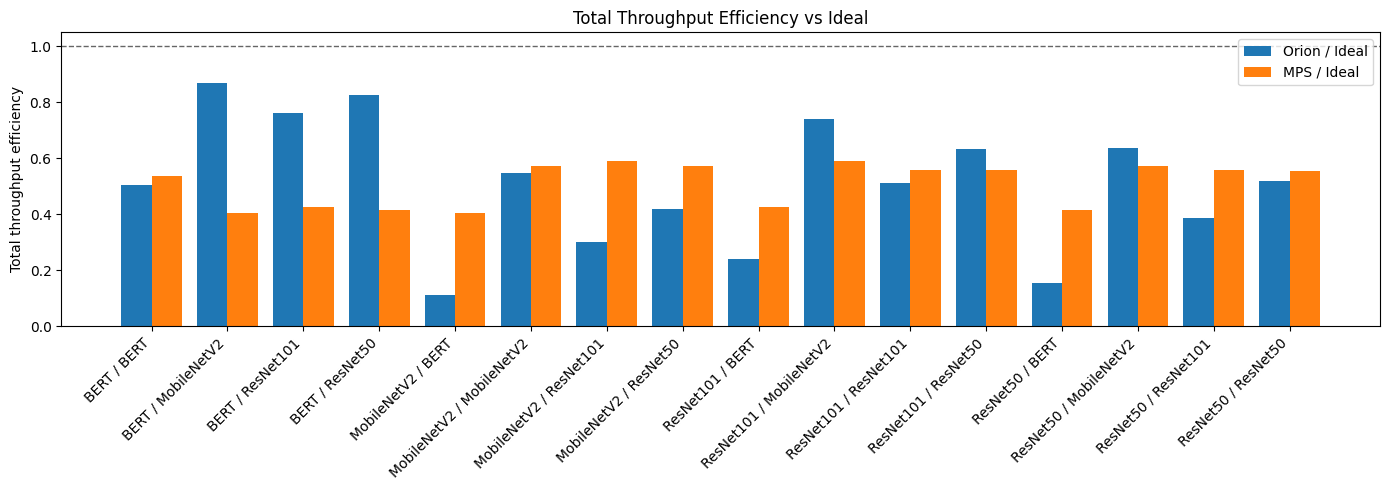

In [ ]:
plot_total_efficiency(df)

## Figure 2: HP p95 slowdown vs Ideal
Lower is better for HP. A value of 1.0 means HP matches isolated performance.

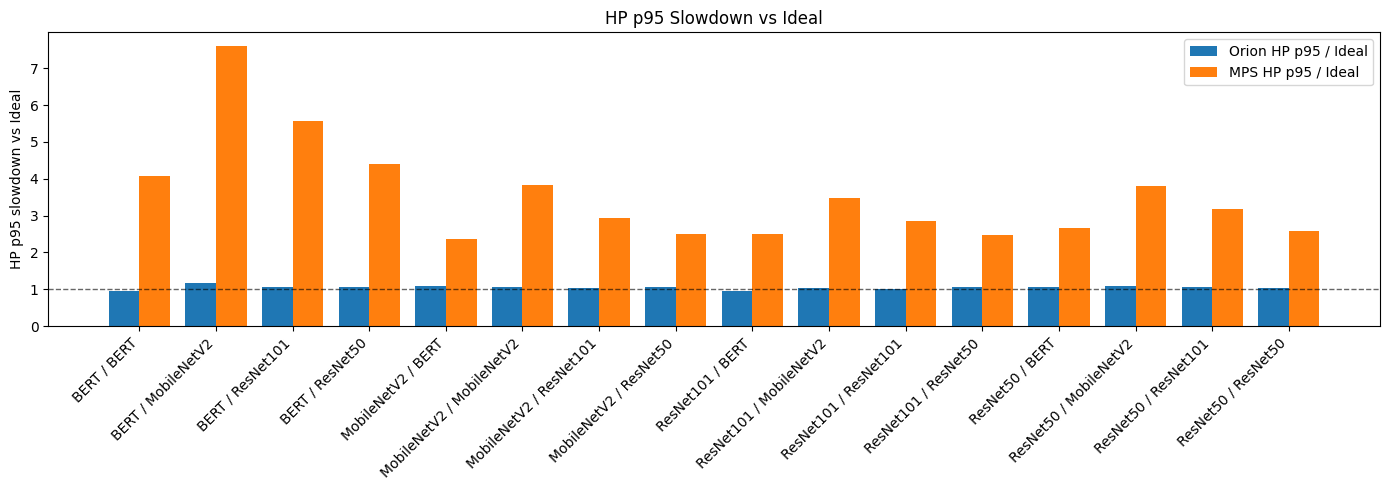

In [ ]:
plot_hp_p95_slowdown(df)

## Figure 3: Tradeoff view (HP protection vs BE progress)
x-axis: BE throughput fraction of isolated (Ideal). Higher is better for BE.
y-axis: HP p95 slowdown vs isolated (Ideal). Lower is better for HP.

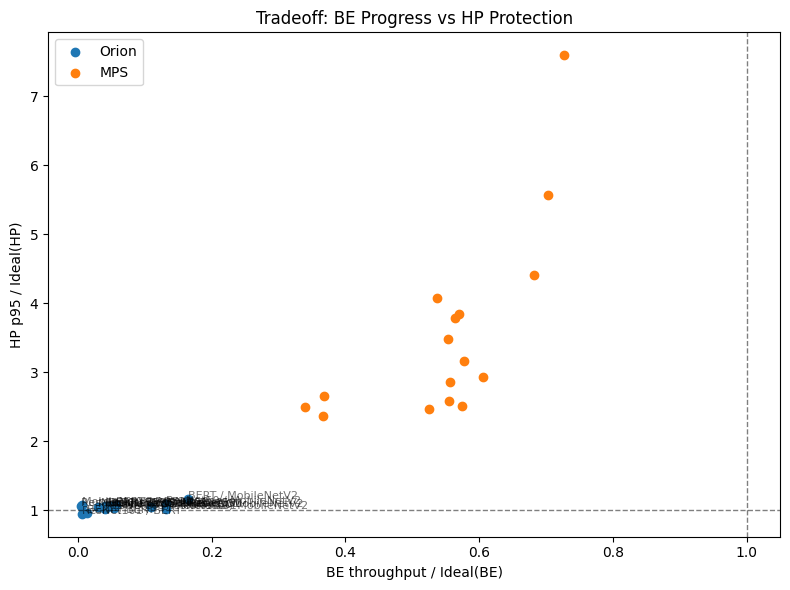

In [ ]:
plot_tradeoff(df)

## Export a summary CSV
Use this to plot externally or archive results.

In [ ]:
out = BASE / 'orion_vs_mps_vs_ideal_summary.csv'
df.to_csv(out, index=False)
print('Wrote', out.resolve())

cols = [
    'be_model','hp_model','run',
    'ideal_be_throughput','ideal_hp_throughput','ideal_total_throughput',
    'orion_be_throughput','orion_hp_throughput','orion_total_throughput','orion_total_efficiency',
    'mps_be_throughput','mps_hp_throughput','mps_total_throughput','mps_total_efficiency',
    'orion_be_thr_frac_of_ideal','mps_be_thr_frac_of_ideal',
    'orion_hp_p95_slowdown','mps_hp_p95_slowdown',
    'orion_hp_p95','mps_hp_p95','ideal_hp_p95',
    'orion_be_p95','mps_be_p95','ideal_be_p95',
 ]
display(df[cols].sort_values(['be_model','hp_model','run']))

Wrote /home/cc/orion/rtx6000_results/inf_inf_updated/orion_vs_mps_vs_ideal_summary.csv


,be_model,hp_model,ideal_be_throughput,ideal_hp_throughput,ideal_total_throughput,orion_be_throughput,orion_hp_throughput,orion_total_throughput,orion_total_efficiency,mps_be_throughput,...,orion_be_thr_frac_of_ideal,mps_be_thr_frac_of_ideal,orion_hp_p95_slowdown,mps_hp_p95_slowdown,orion_hp_p95,mps_hp_p95,ideal_hp_p95,orion_be_p95,mps_be_p95,ideal_be_p95
0,BERT,BERT,17.928219,17.928219,35.856437,0.256153,17.811383,18.067536,0.503885,9.621277,...,0.014288,0.536656,0.963509,4.075562,43033.843839,182029.531717,44663.661587,166293.596220,181935.571384,44663.661587
1,BERT,MobileNetV2,17.928219,150.063218,167.991436,2.946598,143.272253,146.218851,0.870395,13.025837,...,0.164355,0.726555,1.165832,7.593370,17947.954130,116899.740148,15394.974875,55176.697302,76378.803658,44663.661587
2,BERT,ResNet101,17.928219,58.163509,76.091728,0.801706,57.148962,57.950668,0.761590,12.609693,...,0.044718,0.703343,1.066448,5.566475,36905.026996,192630.938601,34605.548847,83291.086793,118492.096186,44663.661587
3,BERT,ResNet50,17.928219,101.185428,119.113646,1.028818,97.474368,98.503186,0.826968,12.233933,...,0.057385,0.682384,1.072513,4.408620,46600.259829,191552.783835,43449.604106,88190.205765,119463.683009,44663.661587
4,MobileNetV2,BERT,150.063218,17.928219,167.991436,0.876720,17.832681,18.709400,0.111371,54.896318,...,0.005842,0.365821,1.075810,2.360872,48049.634802,105445.202076,44663.661587,156802.261305,159984.809172,15394.974875
5,MobileNetV2,MobileNetV2,150.063218,150.063218,300.126435,16.446183,147.602930,164.049113,0.546600,85.618841,...,0.109595,0.570552,1.051447,3.842982,16187.006474,59162.612855,15394.974875,54453.750813,59169.649482,15394.974875
6,MobileNetV2,ResNet101,150.063218,58.163509,208.226727,4.513187,57.746395,62.259582,0.298999,90.824035,...,0.030075,0.605238,1.042145,2.926465,36063.983953,101271.933639,34605.548847,80397.941804,81815.246201,15394.974875
7,MobileNetV2,ResNet50,150.063218,101.185428,251.248645,6.626462,98.541541,105.168003,0.418581,86.071349,...,0.044158,0.573567,1.050033,2.512217,45623.523390,109154.855561,43449.604106,85498.976910,87397.331810,15394.974875
8,ResNet101,BERT,58.163509,17.928219,76.091728,0.352893,17.883992,18.236885,0.239670,19.773113,...,0.006067,0.339957,0.949845,2.491076,42423.546207,111260.576534,44663.661587,160881.441855,181097.180724,34605.548847
9,ResNet101,MobileNetV2,58.163509,150.063218,208.226727,7.695603,146.125712,153.821316,0.738720,32.215993,...,0.132310,0.553887,1.024358,3.485386,15769.968712,53657.432699,15394.974875,55280.537713,65352.332163,34605.548847


## Optional: quick PDF snippet helper (EuroSys'24 Orion PDF)
This extracts a *small* set of numeric “×” claims and tail-latency mentions from the paper PDF **if** you have `pymupdf` installed and the PDF present locally.

It’s meant for quick navigation, not for reproducing the paper.

In [ ]:
import re

paper_path = PAPER_PDF.resolve()
print('paper_path:', paper_path)
if not paper_path.exists():
    print('Paper PDF not found; skipping.')
else:
    try:
        import fitz  # PyMuPDF
    except Exception as e:
        print('PyMuPDF not available. Install with: pip install pymupdf')
        raise
    doc = fitz.open(str(paper_path))
    print('pages:', doc.page_count)

    hits = []
    for i in range(doc.page_count):
        text = doc.load_page(i).get_text('text')
        for m in re.finditer(r'(\d+(?:\.\d+)?)\s*×', text):
            val = float(m.group(1))
            start = max(0, m.start() - 60)
            end = min(len(text), m.end() + 60)
            ctx = re.sub(r'\s+', ' ', text[start:end]).strip()
            hits.append({'page': i+1, 'multiplier_x': val, 'context': ctx[:140]})
        for m in re.finditer(r'tail latency', text, flags=re.IGNORECASE):
            start = max(0, m.start() - 60)
            end = min(len(text), m.end() + 60)
            ctx = re.sub(r'\s+', ' ', text[start:end]).strip()
            hits.append({'page': i+1, 'multiplier_x': None, 'context': ctx[:140]})

    paper_df = pd.DataFrame(hits)
    print('extracted snippets:', len(paper_df))
    display(paper_df.sort_values(['multiplier_x','page'], ascending=[False, True]).head(30))

paper_path: /home/cc/orion/2024_Orion- Interference-aware, Fine-grained GPU Sharing for ML Applications.pdf
pages: 18
extracted snippets: 49


,page,multiplier_x,context
0,1,7.30,erence jobs to increase per-GPU request throug...
3,2,7.30,"ine inference, Orion improves aggregate throug..."
38,12,7.30,- gregate inference throughput by up to 2× (fo...
10,9,3.44,"ffort training job. On average, REEF’s inferen..."
13,10,3.00,"nference job within 14% of the ideal latency, ..."
12,10,2.50,otal throughput. ideal for the Apollo trace ex...
4,2,2.30,- age while increasing the GPU’s aggregate thr...
15,10,2.30,"ime, Orion increases aggregate throughput by u..."
40,12,2.20,y is 3 orders of magnitude higher than ideal)....
37,12,2.00,while increasing ag- gregate inference through...


## Paper-style figures (moved)
The paper-style reproduction (CSV matrices + script-equivalent plots) has been moved to:
- `paper_style_figures.ipynb`